In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# plot Function
def plot_burstiness(result1):
    # Example burst data
    start_times = result1['ts']
    end_times = result1['te']
    counts = result1['count']

    # Bar width = end - start
    widths = [end - start for start, end in zip(start_times, end_times)]

    # All bars at y=0 since burst ID doesn't matter
    y_position = [0] * len(start_times)

    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 3))

    for i in range(len(start_times)):
        ax.bar(
            x=start_times[i],     # left edge of the bar
            height=counts[i],     # height of the bar = count
            width=widths[i],      # width = end - start
            bottom=0,
            align='edge',
            edgecolor='black',
            alpha=0.7,
            label=f"Burst {i+1}",
            color='steelblue'
        )

    ax.set_xlabel("Time")
    ax.set_ylabel("Count")
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)
    ax.set_title("I/O Burst Ranges Over Time")
    # ax.legend()
    # plt.grid(True, axis='x')
    plt.tight_layout()
    plt.show()


# Merge Results:
def merge_close_bursts(result_df):
    """
    Merge bursts in the DataFrame if the time between the end of one burst
    and the start of the next is less than the standard deviation of all such gaps.
    
    Parameters:
    - result_df: DataFrame with columns ['b_id', 'start_time', 'end_time', 'dur', 'size', 'count']
    
    Returns:
    - merged_result: DataFrame with merged bursts
    """

    # Step 1: Sort by start_time
    result_df = result_df.sort_values('start_time').reset_index(drop=True)

    # Step 2: Compute time gap between current end_time and next start_time
    result_df['gap'] = result_df['start_time'].shift(-1) - result_df['end_time']

    # Step 3: Calculate std of gaps, excluding the last row (gap=NaN)
    gap_std = result_df['gap'].dropna().std()

    # Step 4: Assign group IDs based on the std threshold
    group_id = 0
    group_ids = [group_id]
    for i in range(1, len(result_df)):
        if result_df.loc[i - 1, 'gap'] < gap_std:
            group_ids.append(group_id)
        else:
            group_id += 1
            group_ids.append(group_id)
    result_df['group_id'] = group_ids

    # Step 5: Merge the groups
    merged_result = result_df.groupby('group_id').agg(
        start_time=('start_time', 'min'),
        end_time=('end_time', 'max'),
        dur=('dur', 'sum'),
        size=('size', 'sum'),
        count=('count', 'sum')
    ).reset_index(drop=True)

    return merged_result


In [3]:
app_name = "unet3d"
burst_data = "/p/lustre3/pandey2/logs/results_checkpoint/"+app_name+"/data_burst.csv"
df = pd.read_csv(burst_data)
df.head()

,Unnamed: 0,id,name,cat,size,ts,te,dur,trange,mount_point,hostname,b_id
0,0,333723,write,POSIX,32,4597199,4597203,4,0,/dev,corona221,333723
1,1,333724,write,POSIX,-1,4597210,4597215,5,0,/dev,corona221,333723
2,2,333725,write,POSIX,24,4597222,4597225,3,0,/dev,corona221,333723
3,3,333729,write,POSIX,32,4597259,4597263,4,0,/dev,corona221,333723
4,4,169625,write,POSIX,32,4597269,4597274,5,0,/dev,corona221,333723


In [4]:
df.groupby(["mount_point","name"]).count()

Unnamed: 0      id     cat    size      ts      te  \
mount_point       name                                                         
/collab/usr/gapps read          4864    4864    4864    4864    4864    4864   
/dev              read           128     128     128     128     128     128   
                  write         3968    3968    3968    3968    3968    3968   
/g/g92            read           512     512     512     512     512     512   
/proc             read         29824   29824   29824   29824   29824   29824   
/sys              read        154368  154368  154368  154368  154368  154368   
/usr/WS2          fread          128     128     128     128     128     128   
                  read         77824   77824   77824   77824   77824   77824   
/usr/share        read           128     128     128     128     128     128   
/usr/tce          fread          256     256     256     256     256     256   
/usr/workspace    fwrite         256     256     256     256     256     256   
                  write           35      35      35      35      35      35   

                             dur  trange  hostname    b_id  
mount_point       name                                      
/collab/usr/gapps read      4864    4864      4864    4864  
/dev              read       128     128       128     128  
                  write     3968    3968      3968    3968  
/g/g92            read       512     512       512     512  
/proc             read     29824   29824     29824   29824  
/sys              read    154368  154368    154368  154368  
/usr/WS2          fread      128     128       128     128  
                  read     77824   77824     77824   77824  
/usr/share        read       128     128       128     128  
/usr/tce          fread      256     256       256     256  
/usr/workspace    fwrite     256     256       256     256  
                  write       35      35        35      35

# Read Events in /usr/WS2

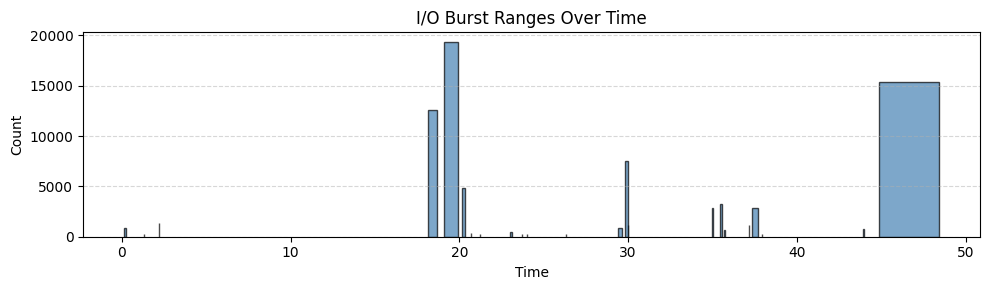

In [5]:
selected_events = df[
    (df['mount_point'] == "/usr/WS2") & (df['name'] == "read")
 ].reset_index(drop=True)

result = selected_events.groupby(['b_id']).agg(
    start_time=('ts', 'min'),
    end_time=('te', 'max'),
    dur = ('dur','sum'),
    size = ('size','sum'),
    count=('ts', 'count')  # or any column — all rows per group are counted
).reset_index()

result['ts'] = result['start_time']/1e6
result['te'] = result['end_time']/1e6
plot_burstiness(result)


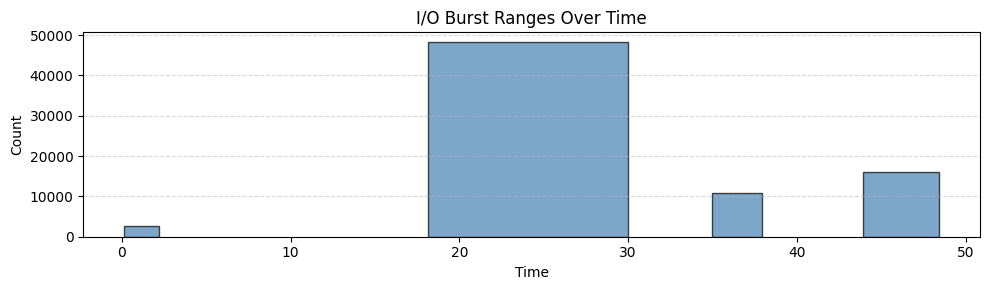

In [6]:
result = merge_close_bursts(result)
result['ts'] = result['start_time']/1e6
result['te'] = result['end_time']/1e6
plot_burstiness(result)

# Read Events in /sys in corona 255

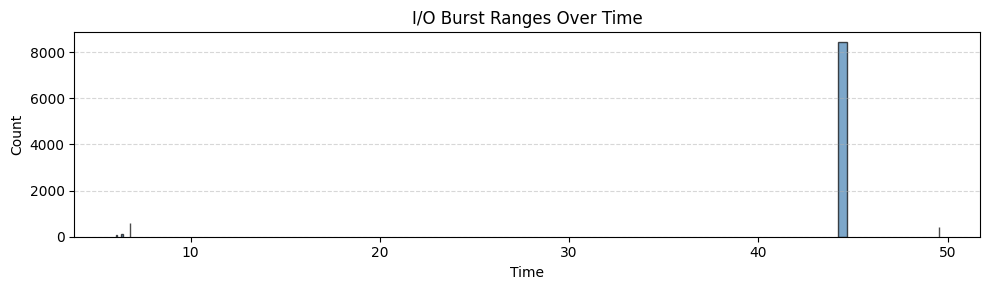

In [7]:
selected_events = df[
    (df['mount_point'] == "/sys") & (df['name'] == "read") & (df['hostname'] == "corona255")
 ].reset_index(drop=True)

result = selected_events.groupby(['b_id']).agg(
    start_time=('ts', 'min'),
    end_time=('te', 'max'),
    dur = ('dur','sum'),
    size = ('size','sum'),
    count=('ts', 'count')  # or any column — all rows per group are counted
).reset_index()

result['ts'] = result['start_time']/1e6
result['te'] = result['end_time']/1e6
plot_burstiness(result)


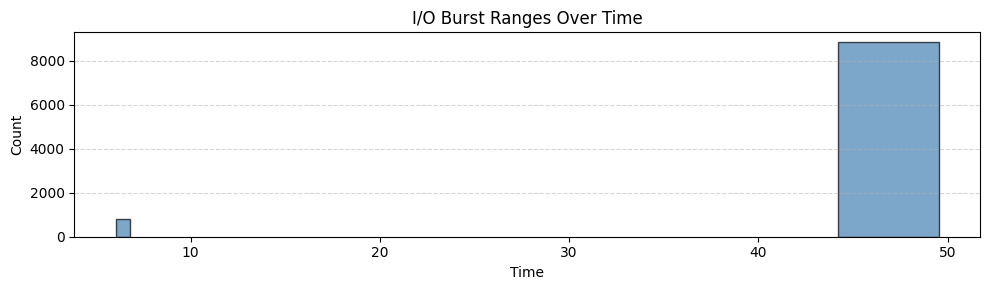

In [8]:
result = merge_close_bursts(result)
result['ts'] = result['start_time']/1e6
result['te'] = result['end_time']/1e6
plot_burstiness(result)